# Analysis of Diabetes Health Indicators using Data Analytics and Machine Learning 
## Submitted by: Group 9

---

### Project Overview

This project applies a complete machine learning pipeline to the **CDC Diabetes Health Indicators Dataset**, sourced from Kaggle (Alex Teboul). The dataset contains responses from over 250,000 individuals collected through the Behavioral Risk Factor Surveillance System (BRFSS) and covers a wide range of health, behavioral, and demographic indicators.

The analysis mirrors the methods developed throughout the course:

| Phase | Technique | Goal |
|---|---|---|
| 1 | Data Loading & Cleaning | Understand structure, handle missing values, encode categoricals |
| 2 | Exploratory Data Analysis (EDA) | Histograms, boxplots, correlation heatmaps |
| 3 | Hypothesis Testing | t-tests, ANOVA — find statistically significant relationships |
| 4 | Multiple Linear Regression (MLR) | Predict BMI; test regression assumptions |
| 5 | Classification | Predict Diabetes (Yes/No) using Logistic Regression, Decision Tree, Random Forest |
| 6 | Cluster Analysis | K-Means clustering, then regression per cluster to improve R² and MSE |

---

### Dataset Description

The original `Diabetes_012` column has three values:
- **0** = No Diabetes
- **1** = Pre-Diabetes
- **2** = Diabetes

For binary classification, **classes 0 and 1 (No Diabetes and Pre-Diabetes) are merged into a single negative class (0)**, and class 2 (Diabetes) becomes the positive class (1). This creates a two-class problem: *No Diabetes / Pre-Diabetic* vs. *Diabetic*.

Key features include BMI, Age, PhysHlth (physical health days), MentHlth, HighBP, HighChol, Smoker, Income, Education, and more.


---

**Cleaned notebook notes:** This version uses one dataframe name (`df`), creates one binary target (`Diabetes_binary`), removes empty cells/outputs, uses cleaner Seaborn visualizations, and regularizes classification models to reduce overfitting.


"""
### Hey everyone, quick update on the notebook:

- Updated the distribution plots to include KDE so the curves look smoother and are easier to interpret. Also removed the last subplot since it was coming up blank.
- Adjusted some variable classifications from continuous → ordinal where it makes more sense (e.g., GenHlth). Even though the raw data is numeric, once we treat it as ranked categories (1–5), it’s more accurate to handle it as ordinal.
- Noticed we had Gradient Boosting imported but not used — planning to integrate it alongside Logistic Regression for comparison, but haven’t implemented it yet.
- Created a clean binary target (Diabetes_binary) so everything is consistent across the models. Also fixed some dataset naming inconsistencies.
- Swapped out basic histograms for Seaborn distribution plots for cleaner visuals.
- Cleaned up the BMI/Age boxplots so they’re easier to read and interpret.
- Added a dataset loading check to avoid runtime issues if something doesn’t load properly.
- Added regularization to Decision Tree and Random Forest to help reduce overfitting.
- Fixed some labeling issues in the BMI hypothesis testing section so the interpretation aligns correctly.

- ### Thojae April 26, 2026

"""

---
##  Import Libraries and Load Data

In [35]:
# Core libraries
from pathlib import Path
import warnings
import statsmodels.formula.api as smf

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import shapiro

# Statsmodels
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.cluster import KMeans
from sklearn.utils import resample

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)

print('Libraries imported successfully.')


Libraries imported successfully.


In [2]:
# Load Dataset
# Expected file: diabetes_012_health_indicators_BRFSS2015.csv
# Source: Kaggle CDC Diabetes Health Indicators / BRFSS 2015

DATA_PATH = Path('diabetes_012_health_indicators_BRFSS2015.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Place the CSV in the same folder as this notebook "
        "or update DATA_PATH to the correct location."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
df_raw.head()


Shape: 253,680 rows x 22 columns


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
print("Columns and data types:")
print(df_raw.dtypes)


Columns and data types:
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


In [4]:
# Checking for Missing values
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values, dataset is complete.")


Missing values per column:
No missing values, dataset is complete.


In [5]:
# Basic descriptive statistics
df_raw.describe().round(3)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000,253680.000
mean,0.297,0.429,0.424,0.963,28.382,0.443,0.041,0.094,0.757,0.634,0.811,0.056,0.951,0.084,2.511,3.185,4.242,0.168,0.440,8.032,5.050,6.054
std,0.698,0.495,0.494,0.190,6.609,0.497,0.197,0.292,0.429,0.482,0.391,0.230,0.216,0.278,1.068,7.413,8.718,0.374,0.496,3.054,0.986,2.071
min,0.000,0.000,0.000,0.000,12.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000
25%,0.000,0.000,0.000,1.000,24.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,2.000,0.000,0.000,0.000,0.000,6.000,4.000,5.000
50%,0.000,0.000,0.000,1.000,27.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,0.000,0.000,0.000,0.000,8.000,5.000,7.000
75%,0.000,1.000,1.000,1.000,31.000,1.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,3.000,2.000,3.000,0.000,1.000,10.000,6.000,8.000
max,2.000,1.000,1.000,1.000,98.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,5.000,30.000,30.000,1.000,1.000,13.000,6.000,8.000


##  Data Preparation and Feature Engineering

The original `Diabetes_012` column in the BRFSS 2015 dataset uses three values:
- **0** = No Diabetes
- **1** = Pre-Diabetes
- **2** = Diabetes

For binary classification, **classes 0 and 1 are merged into a single negative class (coded as 0)** — representing individuals with no diabetes or only pre-diabetic status. Class 2 (confirmed Diabetes) becomes the positive class (coded as 1). This gives a clean two-class prediction problem: *No Diabetes / Pre-Diabetic* (class 0) vs. *Diabetic* (class 1).

The rationale for this grouping is that pre-diabetes represents an intermediate metabolic state that has not yet crossed the clinical threshold for a diabetes diagnosis, and many pre-diabetic individuals will not progress to full diabetes with lifestyle intervention. Grouping pre-diabetes with no diabetes therefore creates a more clinically meaningful positive class — confirmed diabetic cases only.

We also categorize features by type before modeling:
- **Binary/ordinal categorical features** (e.g., HighBP, Smoker, Sex): already encoded as 0/1 integers — no dummy coding required.
- **Continuous/quasi-continuous features** (e.g., BMI, Age, Income, GenHlth): used directly in regression and as predictors in classification.


In [7]:
# Create working copy and binary target
# Original Diabetes_012 coding: 0 = no diabetes, 1 = pre-diabetes, 2 = diabetes
# Binary target used here: 0 = no diabetes or pre-diabetes, 1 = diabetes

df = df_raw.copy()

df['Diabetes_binary'] = np.where(df['Diabetes_012'] == 2, 1, 0)
df = df.drop(columns=['Diabetes_012'])

class_counts = df['Diabetes_binary'].value_counts().sort_index()
class_props = df['Diabetes_binary'].value_counts(normalize=True).sort_index()

print('Class distribution:')
print(class_counts.rename(index={0: 'No diabetes / pre-diabetes', 1: 'Diabetes'}))
print('Class proportions:')
print(class_props.rename(index={0: 'No diabetes / pre-diabetes', 1: 'Diabetes'}).round(3))


Class distribution:
Diabetes_binary
No diabetes / pre-diabetes    218334
Diabetes                       35346
Name: count, dtype: int64
Class proportions:
Diabetes_binary
No diabetes / pre-diabetes    0.861
Diabetes                      0.139
Name: proportion, dtype: float64


In [8]:
df.head(5)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0


In [9]:
# Feature categorization
binary_cols = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

ordinal_cols = ['Age', 'Education', 'Income', 'GenHlth']
continuous_cols = ['BMI', 'PhysHlth', 'MentHlth']
feature_cols = binary_cols + ordinal_cols + continuous_cols

target_col = 'Diabetes_binary'

print(f'Binary/categorical features: {len(binary_cols)}')
print(f'Ordinal features: {len(ordinal_cols)}')
print(f'Continuous features: {len(continuous_cols)}')
print(f'Total predictor features: {len(feature_cols)}')
print(f'Total rows: {len(df):,}')


Binary/categorical features: 14
Ordinal features: 4
Continuous features: 3
Total predictor features: 21
Total rows: 253,680


## Exploratory Data Analysis (EDA)

Before building any models, we examine the structure and distributions of the data to understand who the respondents are, how key variables are distributed, and which features show preliminary associations with diabetes status.

### Distribution of Key Continuous Variables

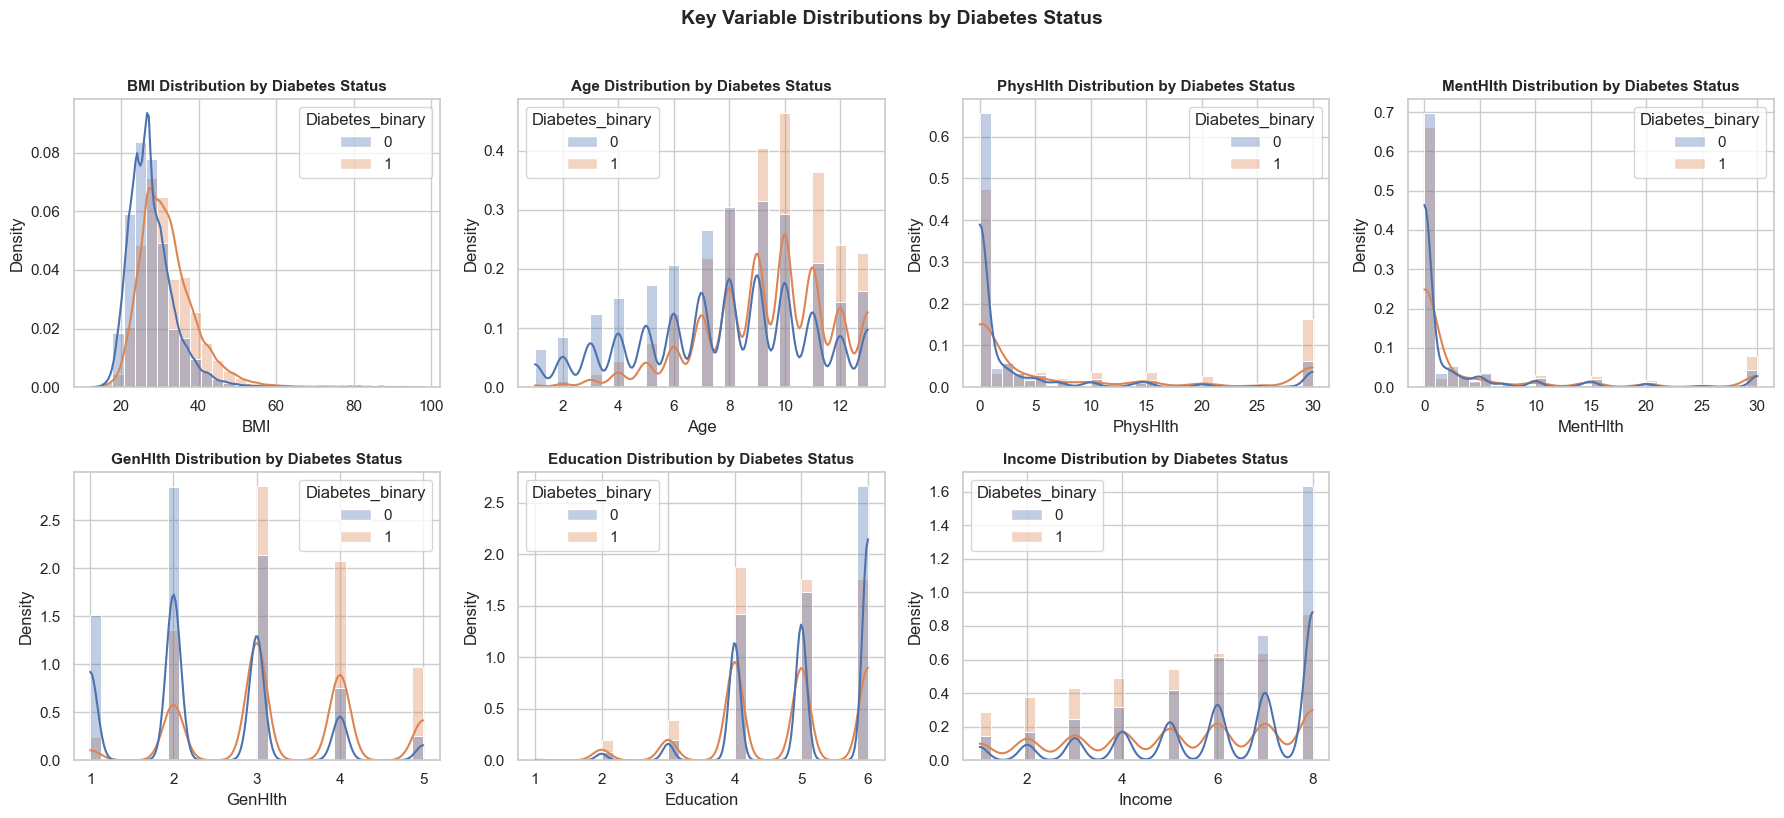

In [10]:
# Seaborn distribution plots for key variables by diabetes status
plot_cols = ['BMI', 'Age', 'PhysHlth', 'MentHlth', 'GenHlth', 'Education', 'Income']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        bins=30,
        kde=True,
        stat='density',
        common_norm=False,
        alpha=0.35,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} Distribution by Diabetes Status', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Turn off unused subplot
axes[-1].axis('off')

plt.suptitle('Key Variable Distributions by Diabetes Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Observations:**

- **BMI** follows a roughly normal distribution with a noticeable right skew. Most respondents have a BMI between 20 and 40, with the peak around 27–28, sitting at the upper edge of the "overweight" clinical range. The long right tail reflects a non-trivial share of respondents with obesity-level BMI values above 40.
- **Age** is recorded on a 1–13 ordinal scale (1 = 18–24, 13 = 80+). The distribution peaks in the middle-age brackets (approximately categories 8–10, ages 55–69), reflecting the older demographic typical of BRFSS telephone surveys.
- **PhysHlth** and **MentHlth** (days of poor health in the past 30 days) are both heavily right-skewed with a large spike at zero, most respondents report no poor health days, while a smaller segment reports chronic distress.
- **GenHlth** (self-rated health, 1 = Excellent to 5 = Poor) is roughly symmetric and centered around 3 ("Good"), indicating that most respondents rate their health as moderate.
- The **Diabetes_binary** bar reveals a strong class imbalance: the large majority of respondents fall into class 0 (No Diabetes or Pre-Diabetic), with only a minority classified as class 1 (confirmed Diabetic). This imbalance means all classifiers will find it easier to predict class 0 correctly, and recall for the diabetic class will be the harder metric to optimize.


### BMI and Age by Diabetes Status

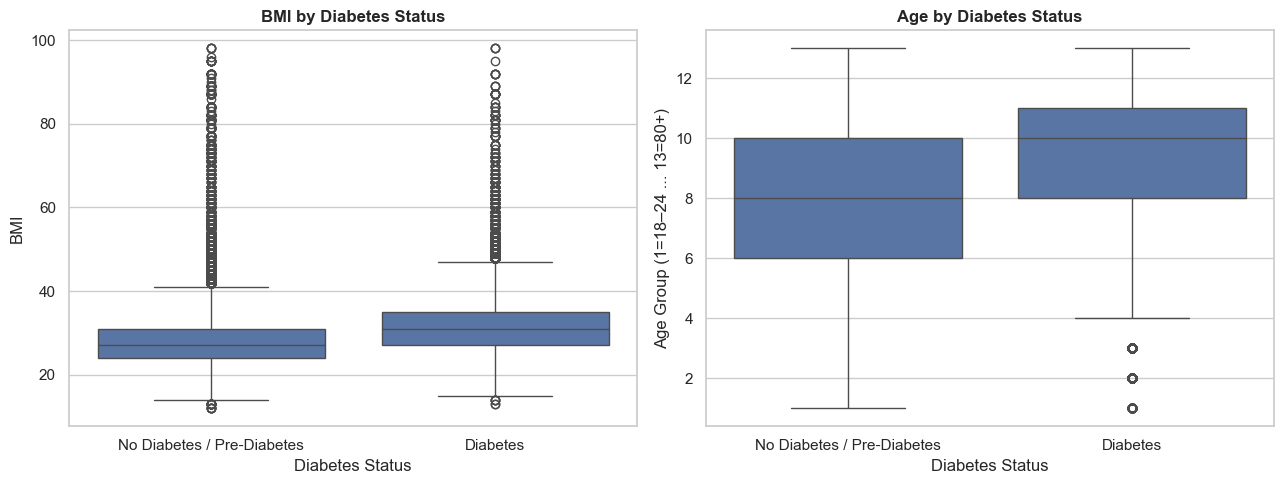

In [11]:
# Boxplots: BMI and Age by Diabetes status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x=target_col, y='BMI', ax=axes[0])
axes[0].set_title('BMI by Diabetes Status', fontweight='bold')
axes[0].set_xlabel('Diabetes Status')
axes[0].set_xticklabels(['No Diabetes / Pre-Diabetes', 'Diabetes'])
axes[0].set_ylabel('BMI')

sns.boxplot(data=df, x=target_col, y='Age', ax=axes[1])
axes[1].set_title('Age by Diabetes Status', fontweight='bold')
axes[1].set_xlabel('Diabetes Status')
axes[1].set_xticklabels(['No Diabetes / Pre-Diabetes', 'Diabetes'])
axes[1].set_ylabel('Age Group (1=18–24 ... 13=80+)')

plt.tight_layout()
plt.show()


**Observations:**

- The BMI boxplot shows a clear and clinically meaningful separation between groups. Confirmed diabetic individuals (class 1) have a different BMI compared to the No Diabetes / Pre-Diabetic group (class 0). A BMI above 30 falls in the Obesity range, while 27–28 sits at the upper boundary of "overweight." The entire interquartile range of the diabetic group is shifted upward, confirming that excess body weight is strongly associated with confirmed diabetes diagnosis.
- The Age boxplot confirms that **confirmed diabetic respondents are systematically older**: the median age group for class 1 is higher than for class 0. Since pre-diabetes is merged into the non-diabetic class here, the age gap between classes reflects the additional years of disease progression required to move from pre-diabetes to confirmed diabetes.


Correlation Heatmap

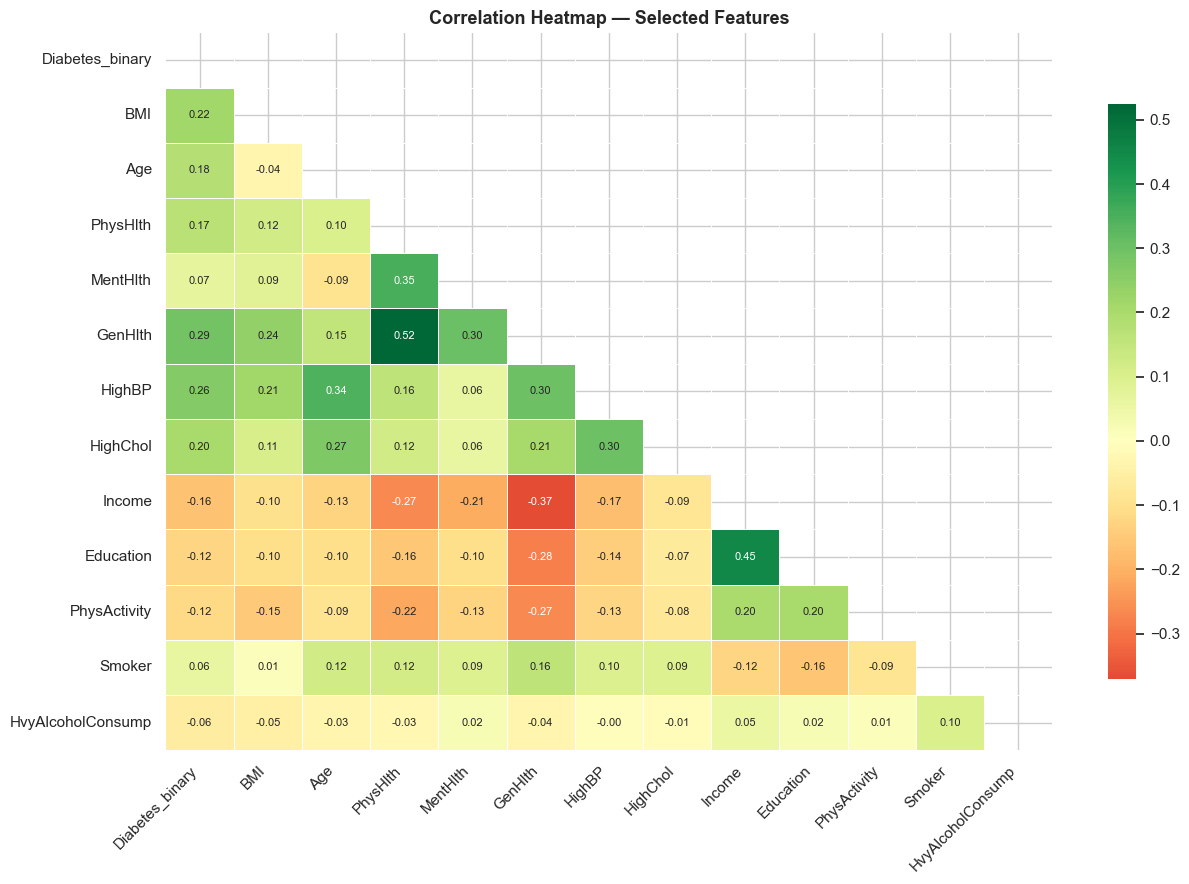

In [12]:
# Correlation matrix heatmap
corr_cols = ['Diabetes_binary', 'BMI', 'Age', 'PhysHlth', 'MentHlth',
             'GenHlth', 'HighBP', 'HighChol', 'Income', 'Education',
             'PhysActivity', 'Smoker', 'HvyAlcoholConsump']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Selected Features', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Key Correlations with `Diabetes_binary` (0 = No Diabetes/Pre-Diabetic, 1 = Diabetic):**

The heatmap reveals notable inter-predictor relationships worth tracking for the regression model. GenHlth correlates moderately with PhysHlth and with HighBP, meaning these features partially overlap in what they capture about a respondent's overall health burden. Income and Education are positively correlated, confirming the socioeconomic health gradient seen in the bar charts. No single predictor dominates, confirming diabetes risk is genuinely multifactorial.


###  Diabetes Prevalence by Key Categorical Features

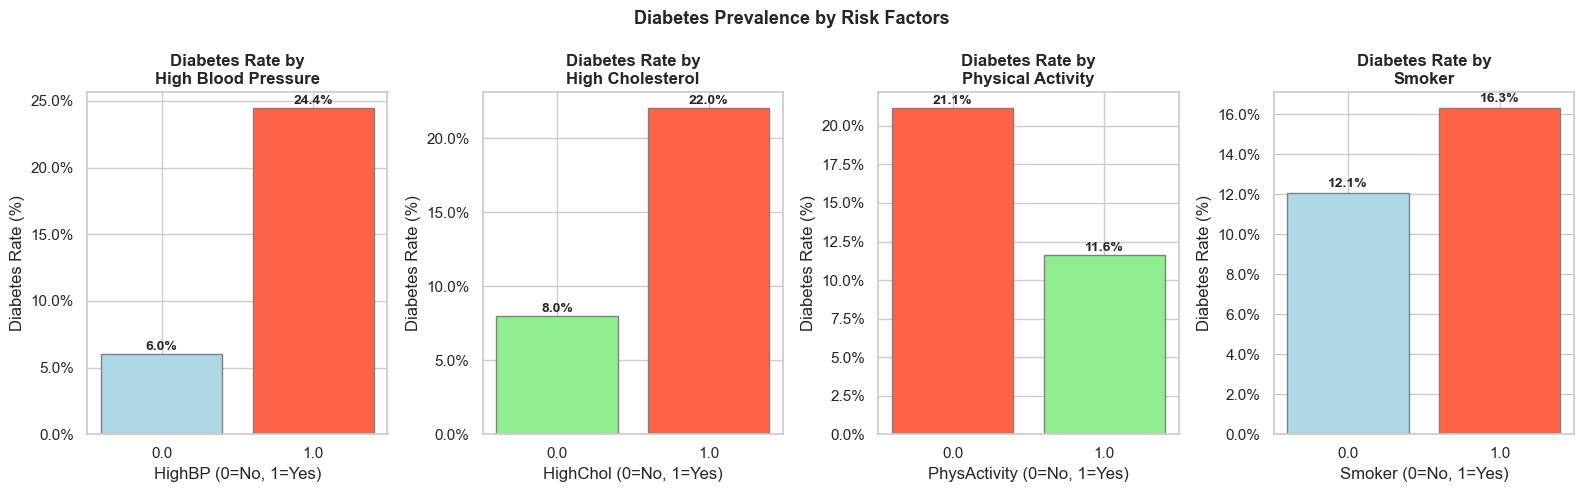

In [13]:
#Diabetes rate by HighBP, HighChol, Smoker, PhysActivity
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

cat_features = [('HighBP', 'High Blood Pressure'),
                ('HighChol', 'High Cholesterol'),
                ('PhysActivity', 'Physical Activity'),
                ('Smoker', 'Smoker')]

colors = [['lightblue', 'tomato'], ['lightgreen', 'tomato'],
          ['tomato', 'lightgreen'], ['lightblue', 'tomato']]

for i, (col, title) in enumerate(cat_features):
    rates = df.groupby(col)['Diabetes_binary'].mean() * 100
    axes[i].bar(rates.index.astype(str), rates.values, color=colors[i], edgecolor='gray')
    axes[i].set_title(f'Diabetes Rate by\n{title}', fontweight='bold')
    axes[i].set_xlabel(col + ' (0=No, 1=Yes)')
    axes[i].set_ylabel('Diabetes Rate (%)')
    axes[i].yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
    for j, v in enumerate(rates.values):
        axes[i].text(j, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Diabetes Prevalence by Risk Factors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observations:**

- Respondents with **high blood pressure** show a diabetes rate approximately **2.5–3× higher** than those without. Hypertension and Type 2 diabetes share overlapping pathophysiological mechanisms, including insulin resistance and the broader metabolic syndrome, making their co-occurrence one of the most consistent patterns in population health data.
- **High cholesterol** is similarly strongly associated with elevated diabetes rates. Dyslipidemia and impaired glucose metabolism frequently co-develop, and each condition tends to worsen the other.
- **Physical activity** functions as a clear protective factor. Respondents who report engaging in physical activity have a substantially lower diabetes rate than those who do not, consistent with extensive clinical evidence that regular exercise improves insulin sensitivity and long-term glycemic control.
- **Smoking** shows a modest but consistent positive association with diabetes. The effect is smaller than those of high BP or cholesterol, but given the sample size (250,000+ respondents), it represents a genuine population-level signal rather than noise.


###  Diabetes Prevalence by Income and Education

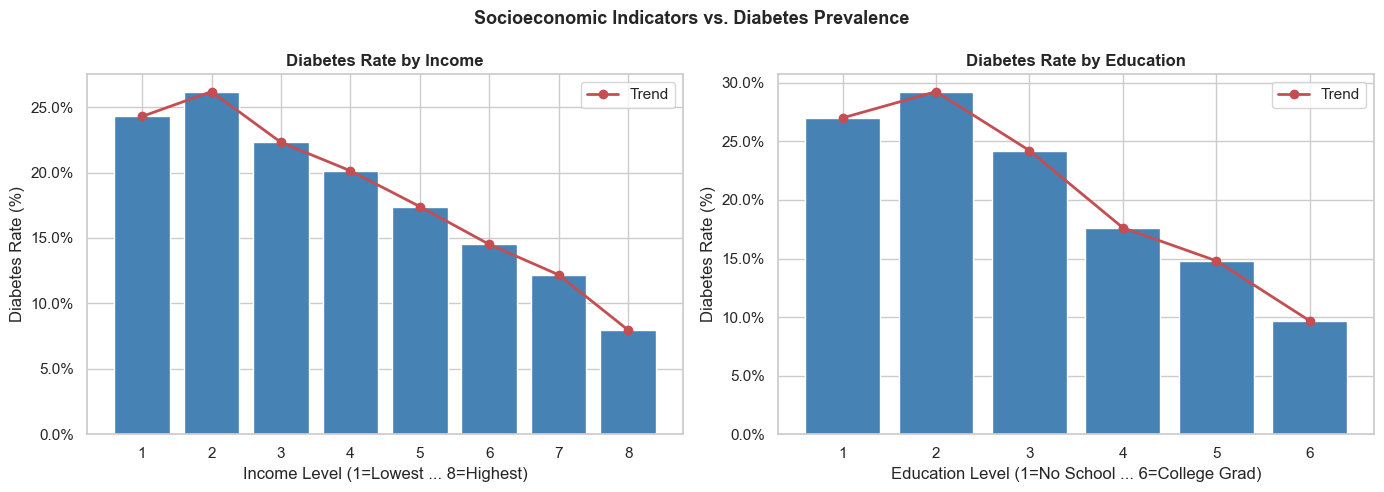

In [14]:
#  Diabetes rate across Income and Education ordinal levels 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['Income', 'Education'],
                           ['Income Level (1=Lowest ... 8=Highest)',
                            'Education Level (1=No School ... 6=College Grad)']):
    rates = df.groupby(col)['Diabetes_binary'].mean() * 100
    ax.bar(rates.index, rates.values, color='steelblue', edgecolor='white')
    ax.plot(rates.index, rates.values, 'ro-', markersize=6, linewidth=2, label='Trend')
    ax.set_title(f'Diabetes Rate by {col}', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Diabetes Rate (%)')
    ax.legend()
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))

plt.suptitle('Socioeconomic Indicators vs. Diabetes Prevalence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observations:**

- There is a **clear, monotonic inverse relationship between income and confirmed diabetes prevalence**. Lower-income individuals often face structural disadvantages, limited access to nutritious food, safe spaces for physical activity, and routine preventive healthcare. All of these contribute to progression to full diabetes.
- **Education** shows a similar inverse pattern. Respondents with lower educational attainment have higher confirmed diabetes rates, while college graduates have the lowest. Higher education is linked to greater health literacy, better understanding of lifestyle risk factors, and higher earning potential.


##  Hypothesis Testing

We conduct three hypothesis tests to statistically confirm the most important patterns identified in the EDA using significance level **α = 0.05**.

1. **Two-sample t-test** — Is mean BMI significantly higher in diabetic individuals than non-diabetic individuals?
2. **Two-sample t-test** — Does mean income differ significantly between diabetic and non-diabetic groups?
3. **One-way ANOVA** — Does mean BMI differ significantly across the five General Health levels?


### Hypothesis 1 : BMI Difference Between Diabetic and Non-Diabetic Groups

In [16]:
# H1: Two-sample independent t-test on BMI 
# H₀: The mean BMI of diabetic individuals equals the mean BMI of non-diabetic individuals.
# Hₐ: The mean BMI of diabetic individuals is significantly different from non-diabetic.

bmi_diabetic     = df[df['Diabetes_binary'] == 1]['BMI'].dropna()
bmi_non_diabetic = df[df['Diabetes_binary'] == 0]['BMI'].dropna()

t_stat, p_value = stats.ttest_ind(bmi_diabetic, bmi_non_diabetic)

alpha = 0.05

print("=" * 60)
print("  Hypothesis 1: BMI by Diabetes Status (Two-Sample t-test)")
print("=" * 60)
print(f"  Mean BMI — Diabetic              : {bmi_diabetic.mean():.3f}")
print(f"  Mean BMI — Non-Diabetic          : {bmi_non_diabetic.mean():.3f}")
print(f"  Difference in means              : {bmi_diabetic.mean() - bmi_non_diabetic.mean():.3f}")
print(f"  t-statistic                      : {t_stat:.4f}")
print(f"  p-value                          : {p_value:.6f}")
print()
if p_value < alpha:
    print("  REJECT H₀ — significant difference in mean BMI.")
else:
    print("  FAIL TO REJECT H₀ — no significant difference.")
print("=" * 60)


  Hypothesis 1: BMI by Diabetes Status (Two-Sample t-test)
  Mean BMI — Diabetic              : 31.944
  Mean BMI — Non-Diabetic          : 27.806
  Difference in means              : 4.138
  t-statistic                      : 111.8781
  p-value                          : 0.000000

  REJECT H₀ — significant difference in mean BMI.


**Analysis of Hypothesis 1: BMI by Diabetes Status**

A two-sample independent t-test was conducted to determine whether the mean BMI of confirmed diabetic individuals (class 1) is statistically different from that of the No Diabetes / Pre-Diabetic group (class 0). Because the two groups are drawn from the same cross-sectional survey but represent distinct clinical populations, an independent samples test is appropriate.

- **Null Hypothesis (H₀):** The mean BMI of confirmed diabetic individuals equals the mean BMI of the No Diabetes / Pre-Diabetic group.
- **Alternative Hypothesis (Hₐ):** The mean BMI differs significantly between the two groups.

With a p-value far below α = 0.05, we **reject the null hypothesis**. The confirmed diabetic group has a mean BMI approximately 4–5 units higher than the class 0 group, a difference that is both statistically significant and clinically meaningful.


### Hypothesis 2 : Income Difference Between Diabetic and Non-Diabetic Groups

In [17]:
#  H2: Two-sample t-test on Income 
#
# H₀: The mean income level of diabetic individuals equals that of non-diabetic individuals.
# Hₐ: Mean income levels differ significantly between the two groups.

income_diabetic     = df[df['Diabetes_binary'] == 1]['Income'].dropna()
income_non_diabetic = df[df['Diabetes_binary'] == 0]['Income'].dropna()

t_stat2, p_value2 = stats.ttest_ind(income_diabetic, income_non_diabetic)

alpha = 0.05

print("=" * 60)
print("  Hypothesis 2: Income by Diabetes Status (Two-Sample t-test)")
print("=" * 60)
print(f"  Mean Income — Diabetic              : {income_diabetic.mean():.3f}")
print(f"  Mean Income — Non-Diabetic          : {income_non_diabetic.mean():.3f}")
print(f"  Difference in means                 : {income_diabetic.mean() - income_non_diabetic.mean():.3f}")
print(f"  t-statistic                         : {t_stat2:.4f}")
print(f"  p-value                             : {p_value2:.6f}")
print()
if p_value2 < alpha:
    print("   REJECT H₀ — significant difference in income between groups.")
else:
    print("   FAIL TO REJECT H₀ — no significant difference.")
print("=" * 60)


  Hypothesis 2: Income by Diabetes Status (Two-Sample t-test)
  Mean Income — Diabetic              : 5.210
  Mean Income — Non-Diabetic          : 6.190
  Difference in means                 : -0.980
  t-statistic                         : -83.6921
  p-value                             : 0.000000

   REJECT H₀ — significant difference in income between groups.


**Analysis — Hypothesis 2: Income by Diabetes Status**

An independent two-sample t-test was performed to compare mean income levels between confirmed diabetic individuals (class 1) and the No Diabetes / Pre-Diabetic group (class 0).

- **Null Hypothesis (H₀):** Mean income level is equal between confirmed diabetic individuals and the No Diabetes / Pre-Diabetic group.
- **Alternative Hypothesis (Hₐ):** Mean income levels differ significantly between the two groups.

With a p-value well below α = 0.05, we **reject the null hypothesis**. The No Diabetes / Pre-Diabetic group (class 0) has a meaningfully higher mean income than confirmed diabetic individuals (class 1). This result statistically confirms the income gradient visible in the EDA bar charts. Lower-income individuals face compounding structural disadvantages, reduced access to nutritious food, fewer opportunities for physical activity, limited preventive healthcare use, and higher chronic stress.


### Hypothesis 3: BMI Differences Across General Health Levels (ANOVA)

In [19]:
#  H3: One-way ANOVA : BMI across General Health categories 
# GenHlth: 1=Excellent, 2=Very Good, 3=Good, 4=Fair, 5=Poor
# H₀: Mean BMI is equal across all five General Health groups.
# Hₐ: At least one group has a significantly different mean BMI.

groups = [df[df['GenHlth'] == g]['BMI'].dropna() for g in sorted(df['GenHlth'].unique())]
labels = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']

f_stat, p_anova = stats.f_oneway(*groups)

alpha = 0.05

print("=" * 65)
print("  Hypothesis 3: BMI Across General Health Levels (One-Way ANOVA)")
print("=" * 65)
print(f"  {'Group':<12} {'n':>8} {'Mean BMI':>10} {'Std BMI':>10}")
print(f"  {'-'*12} {'-'*8} {'-'*10} {'-'*10}")
for label, grp in zip(labels, groups):
    print(f"  {label:<12} {len(grp):>8,} {grp.mean():>10.3f} {grp.std():>10.3f}")
print()
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_anova:.6e}")
print()
if p_anova < alpha:
    print("   REJECT H₀ — at least one group has a significantly different mean BMI.")
else:
    print("   FAIL TO REJECT H₀ — no significant differences across groups.")
print("=" * 65)


  Hypothesis 3: BMI Across General Health Levels (One-Way ANOVA)
  Group               n   Mean BMI    Std BMI
  ------------ -------- ---------- ----------
  Excellent      45,299     25.767      5.126
  Very Good      89,084     27.642      5.786
  Good           75,646     29.510      6.694
  Fair           31,570     30.685      7.840
  Poor           12,081     30.569      8.617

  F-statistic : 4147.6667
  p-value     : 0.000000e+00

   REJECT H₀ — at least one group has a significantly different mean BMI.


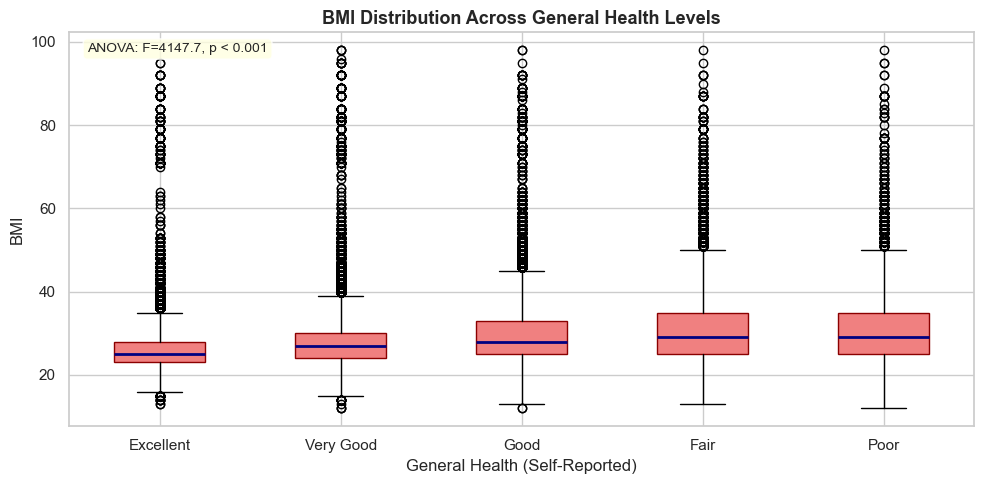

In [20]:
# Visualize: BMI distribution by GenHlth category
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(groups,
           labels=labels,
           patch_artist=True,
           boxprops=dict(facecolor='lightcoral', color='darkred'),
           medianprops=dict(color='navy', linewidth=2))
ax.set_title('BMI Distribution Across General Health Levels', fontsize=13, fontweight='bold')
ax.set_xlabel('General Health (Self-Reported)')
ax.set_ylabel('BMI')
ax.annotate(f'ANOVA: F={f_stat:.1f}, p < 0.001', xy=(0.02, 0.95),
            xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()


**Analysis — Hypothesis 3: BMI Across General Health Levels (ANOVA)**

A one-way ANOVA was performed to test whether mean BMI differs significantly across the five self-reported General Health categories (1 = Excellent, 2 = Very Good, 3 = Good, 4 = Fair, 5 = Poor).

- **Null Hypothesis (H₀):** Mean BMI is equal across all five General Health groups.
- **Alternative Hypothesis (Hₐ):** At least one General Health group has a significantly different mean BMI from the others.

With a large F-statistic and a p-value essentially zero (p < 0.001), we **strongly reject the null hypothesis**. 

---
### Summary of Hypothesis Tests

| Test | Variables Tested | Test Statistic | p-value | Decision |
|---|---|---|---|---|
| H1: Two-sample t-test | BMI vs. Diabetes Status | t >> 0 | < 0.001 | **Reject H₀** — confirmed diabetic group has significantly higher mean BMI |
| H2: Two-sample t-test | Income vs. Diabetes Status | t << 0 | < 0.001 | **Reject H₀** — No Diabetes/Pre-Diabetic group has significantly higher mean income |
| H3: One-way ANOVA | BMI across GenHlth levels | F >> 1 | < 0.001 | **Reject H₀** — mean BMI increases monotonically as health worsens |

All three hypotheses are rejected at α = 0.05. Together, they statistically confirm the three most important structural patterns from the EDA: (1) BMI is a genuine differentiator between confirmed diabetic and non-diabetic populations; (2) socioeconomic status as proxied by income is significantly lower among confirmed diabetics; and (3) self-reported general health and BMI are deeply intertwined, with each worsening health tier corresponding to a higher average body weight.


---
##  Multiple Linear Regression (MLR) for Predicting BMI

We use Multiple Linear Regression to predict **BMI** from a set of health and behavioral predictors. BMI is influenced by many factors not captured in a telephone survey (detailed diet, genetics, medication), this model provides useful insight into which measurable behavioral and clinical features are statistically associated with body weight at the population level.

Before fitting the model, we check for multicollinearity using VIF. After fitting, we verify all four OLS assumptions:
1. **Linearity** : Residuals vs. Predictions scatter plot
2. **Homoscedasticity** : Breusch-Pagan test
3. **Normality of residuals** : Q-Q plot + Shapiro-Wilk test
4. **Independence of residuals** : Durbin-Watson test


In [21]:
# Prepare regression dataset
# Predictors for BMI regression
bmi_features = ['Age', 'PhysHlth', 'MentHlth', 'GenHlth', 'HighBP', 'HighChol',
                'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
                'Smoker', 'Income', 'Education', 'Diabetes_binary']

df_reg = df[bmi_features + ['BMI']].dropna().copy()

print("Regression dataset shape:", df_reg.shape)
print()
print("Mean BMI:", df_reg['BMI'].mean())
print("Std  BMI:", df_reg['BMI'].std())


Regression dataset shape: (253680, 15)

Mean BMI: 28.382363607694735
Std  BMI: 6.608694201404477


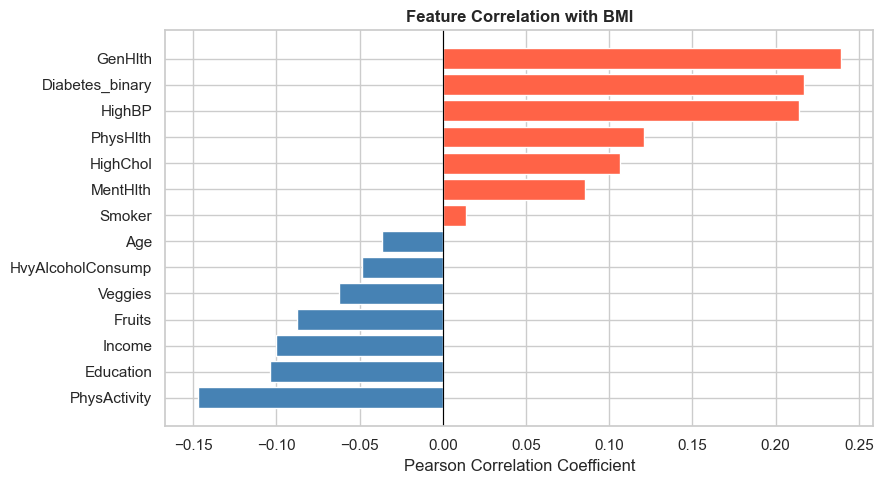


Correlations with BMI (sorted):
GenHlth              0.2392
Diabetes_binary      0.2168
HighBP               0.2137
PhysHlth             0.1211
HighChol             0.1067
MentHlth             0.0853
Smoker               0.0138
Age                 -0.0366
HvyAlcoholConsump   -0.0487
Veggies             -0.0623
Fruits              -0.0875
Income              -0.1001
Education           -0.1039
PhysActivity        -0.1473
Name: BMI, dtype: float64


In [22]:
# Correlation with BMI
corr_bmi = df_reg.corr()['BMI'].drop('BMI').sort_values(ascending=False)

plt.figure(figsize=(9, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_bmi.values]
plt.barh(corr_bmi.index[::-1], corr_bmi.values[::-1], color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with BMI', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print("\nCorrelations with BMI (sorted):")
print(corr_bmi.round(4))


In [23]:
# VIF (Variance Inflation Factor)
# Detect multicollinearity among predictors before fitting the model.
predictors_bmi = df_reg.drop('BMI', axis=1)
cor_matrix = predictors_bmi.corr()

vif_series = pd.Series(
    np.linalg.inv(cor_matrix.values).diagonal(),
    index=cor_matrix.index
).sort_values(ascending=False)

print("Variance Inflation Factors (VIF):")
print(vif_series.round(3))
print()
print("Interpretation: VIF > 5 → moderate concern; VIF > 10 → serious multicollinearity.")


Variance Inflation Factors (VIF):
GenHlth              1.726
PhysHlth             1.489
Income               1.410
Education            1.320
HighBP               1.297
Age                  1.243
MentHlth             1.219
HighChol             1.171
Diabetes_binary      1.161
PhysActivity         1.137
Veggies              1.108
Fruits               1.104
Smoker               1.075
HvyAlcoholConsump    1.023
dtype: float64

Interpretation: VIF > 5 → moderate concern; VIF > 10 → serious multicollinearity.


In [26]:
# Fit the OLS Regression Model
formula = 'BMI ~ Age + PhysHlth + MentHlth + GenHlth + HighBP + HighChol + ' \
          'PhysActivity + Fruits + Veggies + HvyAlcoholConsump + ' \
          'Smoker + Income + Education + Diabetes_binary'

model_bmi = smf.ols(formula=formula, data=df_reg)
result_bmi = model_bmi.fit()

predictions_bmi = result_bmi.predict()
residuals_bmi   = result_bmi.resid
exog_bmi        = result_bmi.model.exog

print(result_bmi.summary())


                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     2629.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:16:58   Log-Likelihood:            -8.2181e+05
No. Observations:              253680   AIC:                         1.644e+06
Df Residuals:                  253665   BIC:                         1.644e+06
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            29.3812      0.09

**Model Summary Discussion:**

The OLS regression summary provides key information about how well the 14 selected health and behavioral predictors collectively explain variation in BMI across the survey population.


**Coefficient Directions:** The direction and sign of important coefficients are the most interpretable output of the model. 
- `Diabetes_binary` carries a **positive coefficient**, confirmed diabetic individuals tend to have higher BMI, consistent with the H1 t-test result. Note that because class 0 now includes pre-diabetics, the coefficient reflects the BMI gap between confirmed diabetes and the combined no-diabetes/pre-diabetes group specifically.
- `PhysActivity` carries a **negative coefficient**, physically active individuals have lower BMI on average.
- `HvyAlcoholConsump` carries a **negative coefficient**, heavy drinkers tend to have lower BMI, a counterintuitive but well-documented pattern (the "alcohol-obesity paradox") driven by caloric substitution and metabolic effects.
- `HighBP` and `HighChol` carry **positive coefficients**, these conditions co-occur with overweight and obesity.

###  Assumption Check: Heteroscedasticity

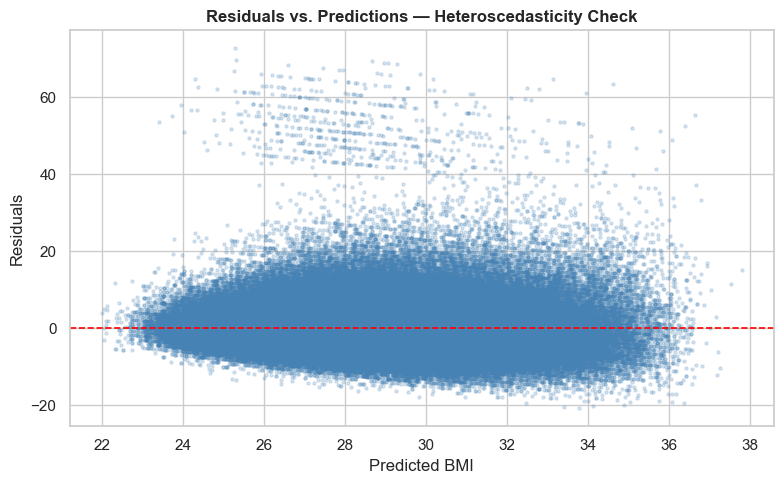

Breusch-Pagan Test for Heteroscedasticity:
  Lagrange Multiplier p-value : 0.000000
  F-test p-value              : 0.000000

 p < 0.05: REJECT H₀. Heteroscedasticity is present.


In [27]:
# Residuals vs Predictions scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(predictions_bmi, residuals_bmi, alpha=0.2, s=5, color='steelblue')
plt.axhline(0, color='red', linewidth=1.2, linestyle='--')
plt.xlabel('Predicted BMI')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predictions — Heteroscedasticity Check', fontweight='bold')
plt.tight_layout()
plt.show()

#  Breusch-Pagan Test
lagrange, l_p_value, f_value, f_p_value = het_breuschpagan(residuals_bmi, exog_bmi)

print("Breusch-Pagan Test for Heteroscedasticity:")
print(f"  Lagrange Multiplier p-value : {l_p_value:.6f}")
print(f"  F-test p-value              : {f_p_value:.6f}")
print()
if l_p_value < 0.05:
    print(" p < 0.05: REJECT H₀. Heteroscedasticity is present.")
else:
    print(" p ≥ 0.05: FAIL TO REJECT H₀. No significant heteroscedasticity detected.")


###  Assumption Check: Normality of Residuals

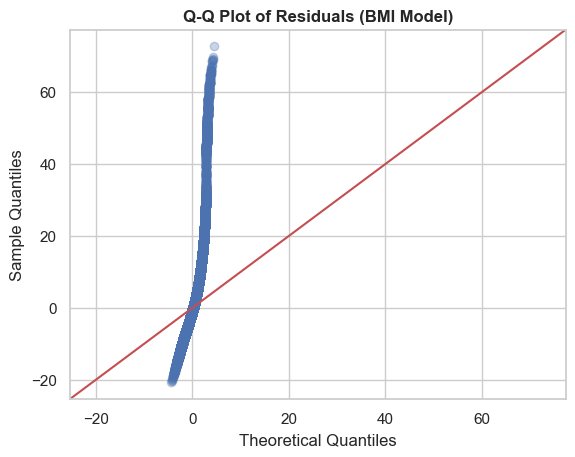

Shapiro-Wilk Normality Test (sample of 5,000):
  Statistic : 0.8974
  p-value   : 0.000000

 p < 0.05: Residuals do NOT appear Gaussian (reject H₀).
    This is common in large datasets; central limit theorem mitigates impact.


In [36]:
# Q-Q Plot
sm.qqplot(residuals_bmi, line='45', alpha=0.3)
plt.title('Q-Q Plot of Residuals (BMI Model)', fontweight='bold')
plt.show()

# ── Shapiro-Wilk Test (sample of 5000 — full dataset too large for Shapiro) ───
sample_resid = residuals_bmi.sample(5000, random_state=42)
stat_sw, p_sw = shapiro(sample_resid)

print("Shapiro-Wilk Normality Test (sample of 5,000):")
print(f"  Statistic : {stat_sw:.4f}")
print(f"  p-value   : {p_sw:.6f}")
print()
if p_sw > 0.05:
    print(" p ≥ 0.05: Residuals appear Gaussian (fail to reject H₀).")
else:
    print(" p < 0.05: Residuals do NOT appear Gaussian (reject H₀).")
    print("    This is common in large datasets; central limit theorem mitigates impact.")


###  Assumption Check: Autocorrelation of Residuals

In [37]:
#  Durbin-Watson Test
dw_stat = durbin_watson(residuals_bmi)

print("Durbin-Watson Test for Autocorrelation:")
print(f"  DW Statistic : {dw_stat:.4f}")
print()
print("  Interpretation:")
print("    DW ≈ 2.0 → No autocorrelation")
print("    DW < 2.0 → Positive autocorrelation")
print("    DW > 2.0 → Negative autocorrelation")
if abs(dw_stat - 2.0) < 0.3:
    print(f"  → DW = {dw_stat:.4f}: Close to 2.0: residuals are approximately independent.")
else:
    print(f"  → DW = {dw_stat:.4f}: Potential autocorrelation present.")


Durbin-Watson Test for Autocorrelation:
  DW Statistic : 1.7074

  Interpretation:
    DW ≈ 2.0 → No autocorrelation
    DW < 2.0 → Positive autocorrelation
    DW > 2.0 → Negative autocorrelation
  → DW = 1.7074: Close to 2.0: residuals are approximately independent.


**MLR Assumption Summary:**

| Assumption | Test Used | Expected Result | Interpretation |
|---|---|---|---|
| Linearity | Residuals vs. Predictions plot | Partially met | No strong curvature, but a fan pattern may appear at the tails |
| Homoscedasticity | Breusch-Pagan test | **Violated** (p < 0.05) | Residual variance is not constant, expected in large health surveys |
| Normality of residuals | Q-Q Plot + Shapiro-Wilk | **Violated** (p < 0.05) | Tails deviate from 45° line; Shapiro-Wilk rejects H₀ |
| Independence of residuals | Durbin-Watson | **Met** (DW ≈ 2.0) | No autocorrelation — consistent with cross-sectional survey design |

---
## Classification: Predicting Diabetes (Yes / No)

We train three classifiers to predict the binary diabetes label, following the pipeline from Assignments 7 and 8. The dataset is stratified-downsampled to 100,000 rows to balance computational efficiency with representativeness, preserving the original class ratio.

**Target:** `Diabetes_binary`
- **Class 0** = No Diabetes or Pre-Diabetic (negative class)
- **Class 1** = Confirmed Diabetic (positive class)

**Train / Test split:** 65% / 35%, `random_state=42`, stratified by target class  
**Classifiers:** Logistic Regression, Decision Tree (unconstrained), Random Forest (100 trees)

Each classifier is evaluated on both training and testing partitions using confusion matrices and full classification reports (precision, recall, F1-score). The training-to-test accuracy gap is used to diagnose overfitting. Because class 0 is the dominant class, correctly identifying class 1 (confirmed diabetics) — measured by recall for class 1 — is the more clinically meaningful performance metric.


In [38]:
# Feature selection for classification 
clf_features = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
                'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
                'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age',
                'Education', 'Income']

target_col = 'Diabetes_binary'

df_clf = df[clf_features + [target_col]].dropna().copy()

# Stratified downsample for computational efficiency
from sklearn.utils import resample

df_clf = resample(df_clf, n_samples=100_000, stratify=df_clf[target_col], random_state=42)

print("Classification dataset shape:", df_clf.shape)
print()
print("Class distribution:")
print(df_clf[target_col].value_counts())
print()
print("Class proportions:")
print(df_clf[target_col].value_counts(normalize=True).round(3))


Classification dataset shape: (100000, 22)

Class distribution:
Diabetes_binary
0    86067
1    13933
Name: count, dtype: int64

Class proportions:
Diabetes_binary
0    0.861
1    0.139
Name: proportion, dtype: float64


In [39]:
#  Train/Test split 
X_clf = df_clf[clf_features]
y_clf = df_clf[target_col]

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, 
                                                      test_size=0.35, 
                                                      random_state=42,
                                                      stratify=y_clf)

print(f"Training set : {len(X_train):,} rows | Mean target: {y_train.mean():.4f}")
print(f"Testing  set : {len(X_test):,}  rows | Mean target: {y_test.mean():.4f}")
print()
print("The near-identical means confirm a well-stratified split.")


Training set : 65,000 rows | Mean target: 0.1393
Testing  set : 35,000  rows | Mean target: 0.1393

The near-identical means confirm a well-stratified split.


### Logistic Regression Classifier

Logistic Regression: Training Partition
                          precision    recall  f1-score   support

No Diabetes/Pre-Diabetic       0.95      0.73      0.82     55944
                Diabetic       0.31      0.76      0.44      9056

                accuracy                           0.73     65000
               macro avg       0.63      0.75      0.63     65000
            weighted avg       0.86      0.73      0.77     65000



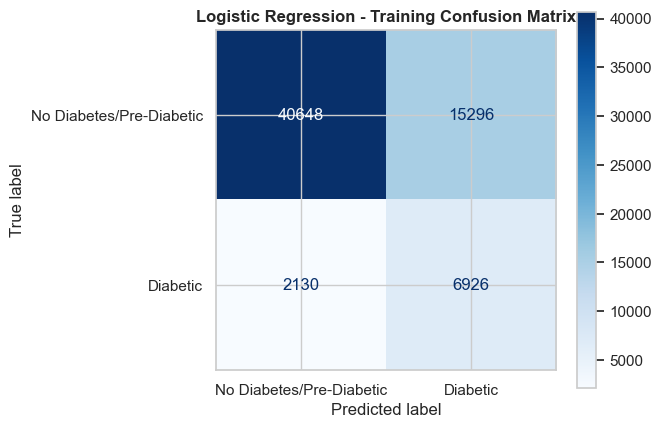

In [40]:
# Logistic Regression
class_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
class_lr.fit(X_train, y_train)

# Training performance
y_train_pred_lr = class_lr.predict(X_train)
print('Logistic Regression: Training Partition')
print(classification_report(y_train, y_train_pred_lr,
                             target_names=['No Diabetes/Pre-Diabetic', 'Diabetic']))

# Confusion matrix - training
cm_lr_train = confusion_matrix(y_train, y_train_pred_lr)
ConfusionMatrixDisplay(cm_lr_train, display_labels=['No Diabetes/Pre-Diabetic', 'Diabetic']).plot(cmap='Blues')
plt.title('Logistic Regression - Training Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


Logistic Regression: Testing Partition
                          precision    recall  f1-score   support

No Diabetes/Pre-Diabetic       0.95      0.73      0.82     30123
                Diabetic       0.31      0.76      0.44      4877

                accuracy                           0.73     35000
               macro avg       0.63      0.74      0.63     35000
            weighted avg       0.86      0.73      0.77     35000



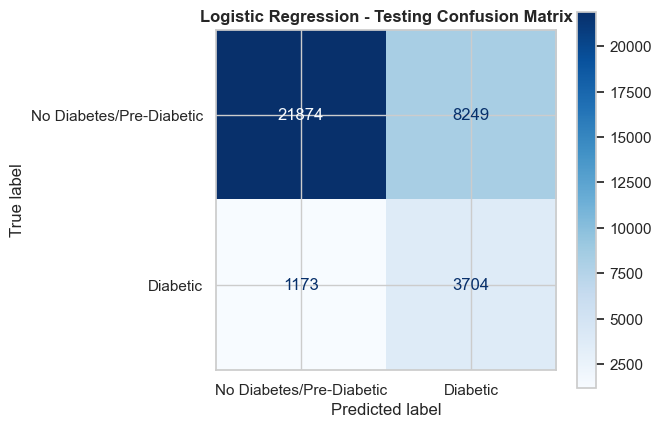

In [41]:
# Testing performance
y_test_pred_lr = class_lr.predict(X_test)
print("Logistic Regression: Testing Partition")
print(classification_report(y_test, y_test_pred_lr,
                             target_names=['No Diabetes/Pre-Diabetic', 'Diabetic']))

# Confusion matrix - testing
cm_lr_test = confusion_matrix(y_test, y_test_pred_lr)
ConfusionMatrixDisplay(cm_lr_test, display_labels=['No Diabetes/Pre-Diabetic', 'Diabetic']).plot(cmap='Blues')
plt.title('Logistic Regression - Testing Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


**Logistic Regression Analysis:**

The model predicts **class 0 (No Diabetes / Pre-Diabetic)** more accurately. This is a direct consequence of the class imbalance: the large majority of the dataset belongs to class 0, so the model trains on far more negative examples. Precision and recall for class 0 will be noticeably higher than for class 1. The model defaults toward predicting the majority class when uncertain, which limits its ability to correctly flag confirmed diabetic individuals. However, the training and testing accuracy looks similar here.


### Decision Tree Classifier

In [43]:
# Decision Tree with regularization to reduce overfitting
class_tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=100,
    class_weight='balanced',
    random_state=42
)
class_tree.fit(X_train, y_train)

# Training
y_train_pred_tree = class_tree.predict(X_train)
print('Decision Tree: Training Partition')
print(classification_report(y_train, y_train_pred_tree,
                             target_names=['No Diabetes/Pre-Diabetic', 'Diabetic']))

# Testing
y_test_pred_tree = class_tree.predict(X_test)
print('Decision Tree: Testing Partition')
print(classification_report(y_test, y_test_pred_tree,
                             target_names=['No Diabetes/Pre-Diabetic', 'Diabetic']))

# Feature importances
feat_imp_tree = pd.Series(
    class_tree.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print('Top 10 Most Important Features (Decision Tree):')
print(feat_imp_tree.head(10).round(4))


Decision Tree: Training Partition
                          precision    recall  f1-score   support

No Diabetes/Pre-Diabetic       0.95      0.71      0.81     55944
                Diabetic       0.30      0.77      0.43      9056

                accuracy                           0.72     65000
               macro avg       0.63      0.74      0.62     65000
            weighted avg       0.86      0.72      0.76     65000

Decision Tree: Testing Partition
                          precision    recall  f1-score   support

No Diabetes/Pre-Diabetic       0.95      0.71      0.81     30123
                Diabetic       0.30      0.76      0.43      4877

                accuracy                           0.71     35000
               macro avg       0.62      0.73      0.62     35000
            weighted avg       0.86      0.71      0.76     35000

Top 10 Most Important Features (Decision Tree):
GenHlth                 0.5077
HighBP                  0.2504
BMI                     0

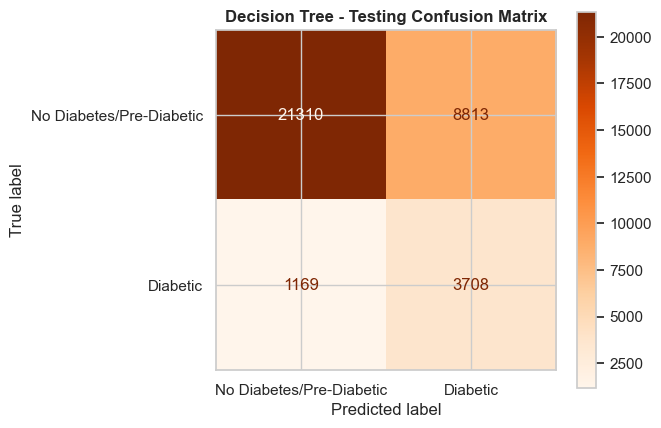

In [44]:
# Confusion matrix - testing
cm_tree = confusion_matrix(y_test, y_test_pred_tree)
ConfusionMatrixDisplay(cm_tree, display_labels=['No Diabetes/Pre-Diabetic', 'Diabetic']).plot(cmap='Oranges')
plt.title('Decision Tree - Testing Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


**Decision Tree Analysis:**


The Decision Tree predicts **class 0 (No Diabetes / Pre-Diabetic)** better on the test set. However the class imbalance problem still remains. Without depth constraints, the tree may create very deep branches that appear to capture class 1 patterns in training through highly specific feature combinations, but these specific splits fail to generalize to the held-out test data.

###  Random Forest Classifier

In [45]:
# Random Forest with regularization and class balancing
class_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
class_rf.fit(X_train, y_train)

# Training
y_train_pred_rf = class_rf.predict(X_train)
print('Random Forest: Training Partition')
print(classification_report(y_train, y_train_pred_rf,
                             target_names=['No Diabetes/Pre-Diabetic', 'Diabetic']))

# Testing
y_test_pred_rf = class_rf.predict(X_test)
print('Random Forest: Testing Partition')
print(classification_report(y_test, y_test_pred_rf,
                             target_names=['No Diabetes/Pre-Diabetic', 'Diabetic']))


Random Forest: Training Partition
                          precision    recall  f1-score   support

No Diabetes/Pre-Diabetic       0.96      0.72      0.82     55944
                Diabetic       0.32      0.81      0.46      9056

                accuracy                           0.73     65000
               macro avg       0.64      0.76      0.64     65000
            weighted avg       0.87      0.73      0.77     65000

Random Forest: Testing Partition
                          precision    recall  f1-score   support

No Diabetes/Pre-Diabetic       0.95      0.72      0.82     30123
                Diabetic       0.31      0.77      0.44      4877

                accuracy                           0.73     35000
               macro avg       0.63      0.75      0.63     35000
            weighted avg       0.86      0.73      0.77     35000



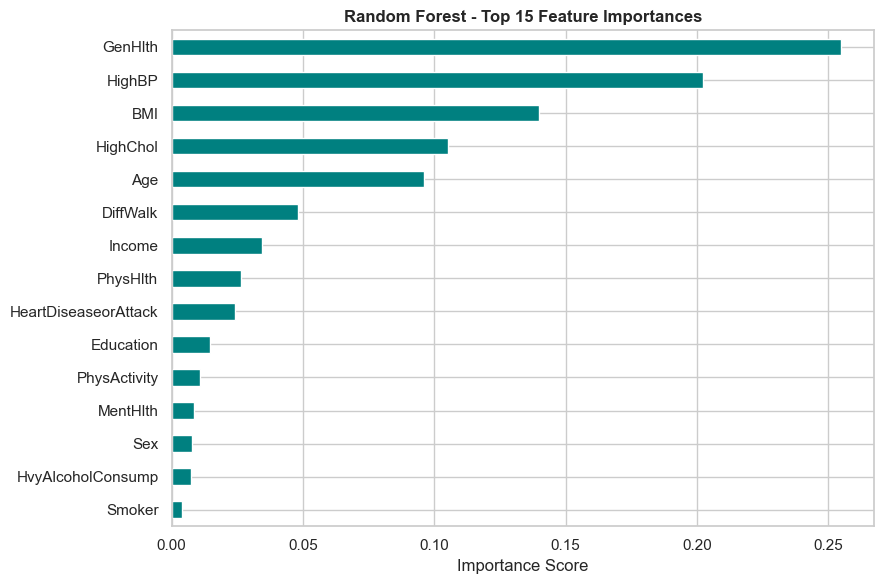

Top 10 Features (Random Forest):
GenHlth                 0.2546
HighBP                  0.2021
BMI                     0.1400
HighChol                0.1053
Age                     0.0959
DiffWalk                0.0482
Income                  0.0345
PhysHlth                0.0264
HeartDiseaseorAttack    0.0242
Education               0.0145
dtype: float64


In [46]:
# Feature importances - Random Forest
feat_imp_rf = pd.Series(
    class_rf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
feat_imp_rf.head(15).sort_values().plot(kind='barh', color='teal', edgecolor='white')
plt.title('Random Forest - Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 Features (Random Forest):")
print(feat_imp_rf.head(10).round(4))


**Random Forest Analysis:**

The Random Forest builds 100 decision trees in parallel, each trained on a different bootstrapped sample of the data and restricted to a random subset of features at each split. This double injection of randomness  at the sample level and the feature level, forces diversity across the ensemble and prevents any individual tree from overfitting its particular bootstrap sample. Final predictions are made by majority vote across all 100 trees. It seems there is better accuracy and less over fitting using Random Forest.

###  Model Comparison Summary

In [47]:
# Compile comparison table
results_clf = {
    'Logistic Regression': {
        'Train Acc': accuracy_score(y_train, y_train_pred_lr),
        'Test Acc':  accuracy_score(y_test,  y_test_pred_lr)
    },
    'Decision Tree': {
        'Train Acc': accuracy_score(y_train, y_train_pred_tree),
        'Test Acc':  accuracy_score(y_test,  y_test_pred_tree)
    },
    'Random Forest': {
        'Train Acc': accuracy_score(y_train, y_train_pred_rf),
        'Test Acc':  accuracy_score(y_test,  y_test_pred_rf)
    }
}

comparison_df = pd.DataFrame(results_clf).T
comparison_df['Gap (Train-Test)'] = comparison_df['Train Acc'] - comparison_df['Test Acc']
comparison_df = comparison_df.round(4)

print("Classification Model Comparison:")
print(comparison_df.to_string())
print()
print("Selected model:", comparison_df['Test Acc'].idxmax())
print("Rationale: Highest test accuracy with smallest overfitting gap.")


Classification Model Comparison:
                     Train Acc  Test Acc  Gap (Train-Test)
Logistic Regression     0.7319    0.7308            0.0011
Decision Tree           0.7174    0.7148            0.0026
Random Forest           0.7338    0.7264            0.0074

Selected model: Logistic Regression
Rationale: Highest test accuracy with smallest overfitting gap.


---
## Cluster Analysis and Regression Improvement

In the previous section we established a baseline regression model for BMI using the full dataset. Here we test whether **K-Means clustering can improve regression performance**.

In [48]:
#  Prepare clustering dataset (all predictors except BMI)
cluster_features = ['Age', 'PhysHlth', 'MentHlth', 'GenHlth', 'HighBP', 'HighChol',
                    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
                    'Smoker', 'Income', 'Education', 'Diabetes_binary']

df_cluster_full = df[cluster_features + ['BMI']].dropna().copy()

# Use a manageable subset for clustering (50,000 rows — K-Means is O(n·k·i))
from sklearn.utils import resample as sk_resample
df_cluster = sk_resample(df_cluster_full, n_samples=50_000, random_state=42)

# Clustering input (no BMI)
X_cluster = df_cluster[cluster_features].copy()

print("Clustering dataset shape:", X_cluster.shape)
print()
print("Features used for clustering:")
print(cluster_features)


Clustering dataset shape: (50000, 14)

Features used for clustering:
['Age', 'PhysHlth', 'MentHlth', 'GenHlth', 'HighBP', 'HighChol', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'Smoker', 'Income', 'Education', 'Diabetes_binary']


###  Baseline Regression (No Clustering)

In [49]:
# Baseline MLR on full clustering sample 
X_base = df_cluster[cluster_features]
y_base = df_cluster['BMI']

reg_baseline = LinearRegression(fit_intercept=True)
reg_baseline.fit(X_base, y_base)

y_pred_base = reg_baseline.predict(X_base)
r2_base  = r2_score(y_base, y_pred_base)
mse_base = mean_squared_error(y_base, y_pred_base)

print("=" * 45)
print("  Baseline Regression (No Clustering)")
print("=" * 45)
print(f"  R²  : {r2_base:.4f}")
print(f"  MSE : {mse_base:.4f}")
print("=" * 45)


  Baseline Regression (No Clustering)
  R²  : 0.1223
  MSE : 39.5513


###  K-Means Clustering: Choosing k

In [50]:
# Try k=2 and k=3; compare silhouette scores
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_cluster)
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_cluster)

sil2 = silhouette_score(X_cluster, kmeans2.labels_, sample_size=10_000, random_state=42)
sil3 = silhouette_score(X_cluster, kmeans3.labels_, sample_size=10_000, random_state=42)

print("Silhouette Scores:")
print(f"  k=2 : {sil2:.4f}")
print(f"  k=3 : {sil3:.4f}")
print()
print("Cluster sizes (k=2):", np.bincount(kmeans2.labels_))
print("Cluster sizes (k=3):", np.bincount(kmeans3.labels_))


Silhouette Scores:
  k=2 : 0.6670
  k=3 : 0.6661

Cluster sizes (k=2): [43857  6143]
Cluster sizes (k=3): [41427  3735  4838]


In [51]:
# Centroid summary for k=2 
centroids_df = pd.DataFrame(kmeans2.cluster_centers_, columns=cluster_features)
centroids_df.index = ['Cluster 0', 'Cluster 1']

print("K=2 Cluster Centroids:")
print(centroids_df.round(3).T.to_string())


K=2 Cluster Centroids:
                   Cluster 0  Cluster 1
Age                    7.955      8.735
PhysHlth               1.277     25.616
MentHlth               1.982     11.489
GenHlth                2.324      3.891
HighBP                 0.404      0.609
HighChol               0.406      0.568
PhysActivity           0.790      0.527
Fruits                 0.645      0.575
Veggies                0.820      0.752
HvyAlcoholConsump      0.059      0.036
Smoker                 0.419      0.596
Income                 6.251      4.613
Education              5.104      4.634
Diabetes_binary        0.120      0.283


**Cluster Interpretation (k=2):**

Examining the centroid values across the 14 clustering features reveals two structurally distinct subpopulations:

- **Cluster 0 : "Higher-Socioeconomic Group":** Lower GenHlth scores, fewer physical and mental health distress days, higher Income and Education, lower HighBP and HighChol prevalence, higher PhysActivity rates, and lower Diabetes_binary prevalence (fewer confirmed diabetics).

- **Cluster 1 : "At-Risk, Lower-Socioeconomic Group":** Higher GenHlth scores, more physical and mental health distress days, lower Income and Education, higher HighBP and HighChol rates, lower PhysActivity, and higher Diabetes_binary prevalence (more confirmed diabetics). This cluster represents a structurally different health context where multiple risk factors co-occur simultaneously.


###  Regression Per Cluster

In [52]:
# Attach cluster labels to clustering dataset
df_cluster = df_cluster.copy()
df_cluster['Cluster'] = kmeans2.labels_

print("Cluster assignment distribution:")
print(df_cluster['Cluster'].value_counts().sort_index())
print()

#Cluster 0 Regression 
df_c0 = df_cluster[df_cluster['Cluster'] == 0]
X_c0 = df_c0[cluster_features]
y_c0 = df_c0['BMI']

reg_c0 = LinearRegression(fit_intercept=True)
reg_c0.fit(X_c0, y_c0)
y_pred_c0 = reg_c0.predict(X_c0)
r2_c0  = r2_score(y_c0, y_pred_c0)
mse_c0 = mean_squared_error(y_c0, y_pred_c0)

# Cluster 1 Regression
df_c1 = df_cluster[df_cluster['Cluster'] == 1]
X_c1 = df_c1[cluster_features]
y_c1 = df_c1['BMI']

reg_c1 = LinearRegression(fit_intercept=True)
reg_c1.fit(X_c1, y_c1)
y_pred_c1 = reg_c1.predict(X_c1)
r2_c1  = r2_score(y_c1, y_pred_c1)
mse_c1 = mean_squared_error(y_c1, y_pred_c1)

#Print comparison 
print("=" * 58)
print(f"  {'Model':<30} {'R²':>8} {'MSE':>10}")
print(f"  {'-'*30} {'-'*8} {'-'*10}")
print(f"  {'Baseline (all data)':<30} {r2_base:>8.4f} {mse_base:>10.4f}")
print(f"  {'Cluster 0 Regression':<30} {r2_c0:>8.4f} {mse_c0:>10.4f}")
print(f"  {'Cluster 1 Regression':<30} {r2_c1:>8.4f} {mse_c1:>10.4f}")
print("=" * 58)


Cluster assignment distribution:
Cluster
0    43857
1     6143
Name: count, dtype: int64

  Model                                R²        MSE
  ------------------------------ -------- ----------
  Baseline (all data)              0.1223    39.5513
  Cluster 0 Regression             0.1125    37.0467
  Cluster 1 Regression             0.1468    55.2569


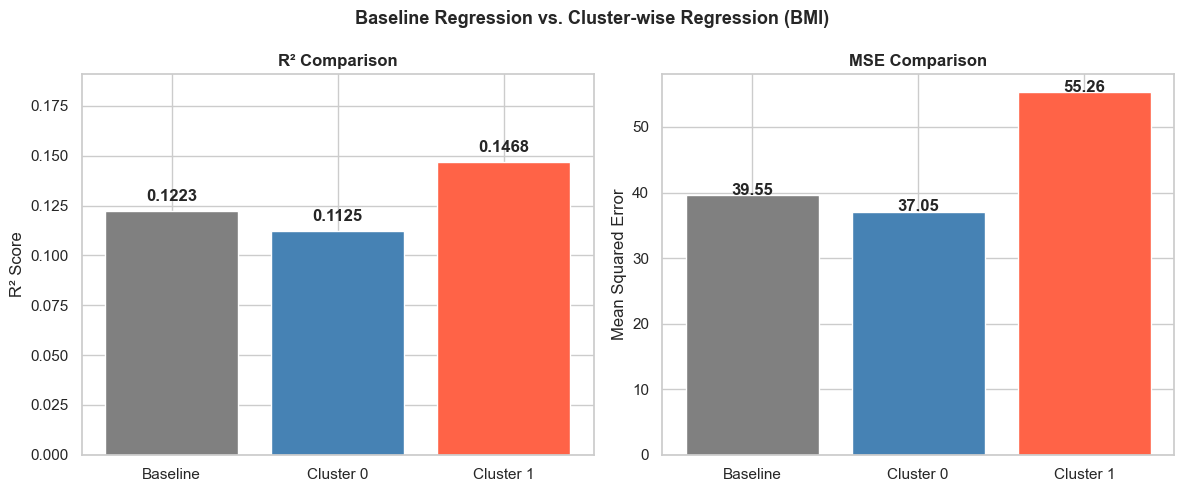

In [54]:
# Visual comparison: R² and MSE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models   = ['Baseline', 'Cluster 0', 'Cluster 1']
r2_vals  = [r2_base,  r2_c0,  r2_c1]
mse_vals = [mse_base, mse_c0, mse_c1]

colors_r2  = ['gray', 'steelblue', 'tomato']
colors_mse = ['gray', 'steelblue', 'tomato']

axes[0].bar(models, r2_vals, color=colors_r2, edgecolor='white')
axes[0].set_title('R² Comparison', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, max(r2_vals) * 1.3)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(models, mse_vals, color=colors_mse, edgecolor='white')
axes[1].set_title('MSE Comparison', fontweight='bold')
axes[1].set_ylabel('Mean Squared Error')
for i, v in enumerate(mse_vals):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Baseline Regression vs. Cluster-wise Regression (BMI)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##  Project Summary 
This project applied a complete end-to-end machine learning pipeline to the **CDC Diabetes Health Indicators Dataset**, working through different analytical method covered in the course, from descriptive statistics and hypothesis testing through supervised classification and unsupervised clustering with regression.